## Вариант 4

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from matplotlib import pyplot as plt
import seaborn as sns
import arviz
import warnings

warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

sns.set_style("ticks",{'axes.grid' : True})
sns.set_theme(rc={'figure.figsize':(8, 8)})

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/fifa_players_stats.csv")
df.sample(5)

,Known As,Full Name,Overall,Potential,Value(in Euro),Positions Played,Best Position,Nationality,Image Link,Age,...,LM Rating,CM Rating,RM Rating,LWB Rating,CDM Rating,RWB Rating,LB Rating,CB Rating,RB Rating,GK Rating
16201,E. Ifoni,Ejaita Ifoni,58,65,425000,ST,ST,Nigeria,https://cdn.sofifa.net/players/270/697/23_60.png,22,...,53,47,53,42,40,42,41,42,41,15
13644,Y. Yarmoliuk,Yehor Yarmoliuk,62,80,1000000,"CAM,CM,RM",RM,Ukraine,https://cdn.sofifa.net/players/270/608/23_60.png,18,...,65,62,65,55,54,55,53,49,53,15
11037,E. Watt,Elliot Watt,64,73,1200000,CDM,RWB,Scotland,https://cdn.sofifa.net/players/241/982/23_60.png,22,...,65,65,65,66,65,66,65,62,65,16
149,W. Ndidi,Wilfred Ndidi,84,86,47500000,"CDM,CM",CB,Nigeria,https://cdn.sofifa.net/players/226/790/23_60.png,25,...,72,78,72,81,84,81,81,85,81,22
11053,Rodrigo Andrade,Rodrigo Marcos Rodrigues Andrade,64,76,1400000,CM,CM,Portugal,https://cdn.sofifa.net/players/264/308/23_60.png,20,...,65,66,65,62,64,62,61,61,61,17


### Задание 1

*Проверьте согласованность общего рейтинга футболиста (атрибут Overall) с нормальным законом*

Для решения будет использован критерий согласия Колмогорова и критерий согласия Пирсона Хи-квадрат

$H_0$: общий рейтинг футболистов распределен нормально

$H_a$: общий рейтинг футболистов не распределен нормально

In [ ]:
def ecdf(a):
    x, counts = np.unique(a, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]

In [ ]:
X, ecdf_values = ecdf(stats.zscore(df["Overall"]))
cdf_values = stats.norm.cdf(X)
D = abs(ecdf_values - cdf_values).max().item()
D_stat = D * np.sqrt(len(df)).item()

alpha = 0.05

D_critical_value = stats.kstwobign.ppf(1 - alpha).item()
p_value = stats.kstwobign.sf(D * np.sqrt(len(df))).item()

In [ ]:
print(f"Для теста Колмогорова-Смирнова {D_stat=} \n{D_critical_value=} \t {p_value=}")
if D_stat > D_critical_value or p_value < alpha:
  print("Нулевая гипотеза отвергается")
else:
  print("Нулевая гипотеза не может быть отвергнута")

Для теста Колмогорова-Смирнова D_stat=6.2551459424348765 
D_critical_value=1.3580986393225505 	 p_value=2.0695657859635904e-34
Нулевая гипотеза отвергается


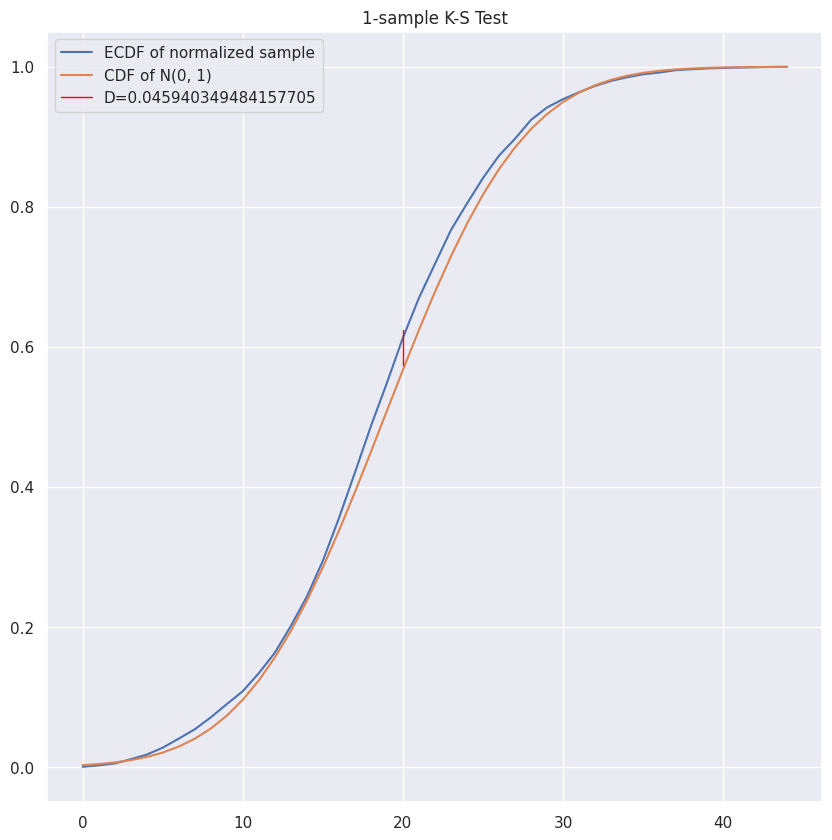

In [ ]:
D_argmax = abs(ecdf_values - cdf_values).argmax()
D_e, D_c = ecdf_values[D_argmax], cdf_values[D_argmax]

plt.figure(figsize=(10, 10))
plt.plot(ecdf_values, label="ECDF of normalized sample")
plt.plot(cdf_values, label="CDF of N(0, 1)")
plt.axvline(D_argmax, ymin=min(D_c, D_e), ymax=max(D_c, D_e), label=f"D={D}", color="red", linewidth=1)
plt.title("1-sample K-S Test")
plt.legend()

In [ ]:
mu, sigma = np.mean(df["Overall"]), np.std(df["Overall"], ddof=1)

bins = np.histogram_bin_edges(df["Overall"], bins=10)
observed, _ = np.histogram(df["Overall"], bins=bins)

expected = []
n = len(df["Overall"])
for i in range(len(bins) - 1):
    p = stats.norm.cdf(bins[i+1], mu, sigma) - stats.norm.cdf(bins[i], mu, sigma)
    expected.append(p * n)
expected = np.array(expected)

chi2_stat = ((observed - expected)**2 / expected).sum().item()
dfr = len(bins) - 1 - 2
chi_critical_value = stats.chi2.ppf(1 - alpha, dfr).item()
p_value = (1 - stats.chi2.cdf(chi2_stat, dfr)).item()

In [ ]:
print(f"Для теста критерия согласия Пирсона Хи-квадрат {chi2_stat=} \n{chi_critical_value=} \t {p_value=}")
if chi2_stat > chi_critical_value or p_value < alpha:
  print("Нулевая гипотеза отвергается")
else:
  print("Нулевая гипотеза не может быть отвергнута")

Для теста критерия согласия Пирсона Хи-квадрат chi2_stat=128.42211531471304 
chi_critical_value=15.50731305586545 	 p_value=0.0
Нулевая гипотеза отвергается


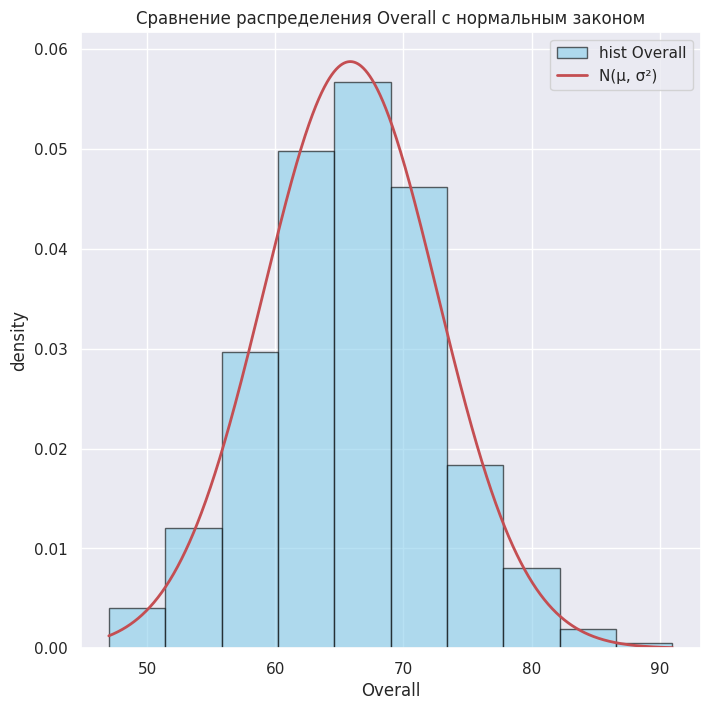

In [ ]:
plt.hist(df["Overall"], bins=bins, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='hist Overall')

x = np.linspace(min(df["Overall"]), max(df["Overall"]), 1000)
pdf = stats.norm.pdf(x, mu, sigma)
plt.plot(x, pdf, 'r-', lw=2, label='N(μ, σ²)')

plt.title('Сравнение распределения Overall с нормальным законом')
plt.xlabel('Overall')
plt.ylabel('density')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
shapiro = stats.shapiro(df["Overall"])
shapiro_stat = shapiro.statistic.item()
p_value = shapiro.pvalue.item()
print(f"Для теста критерия Шапиро-Уилка {shapiro_stat=} \t {p_value=}")
if p_value < alpha:
  print("Нулевая гипотеза отвергается")
else:
  print("Нулевая гипотеза не может быть отвергнута")

Для теста критерия Шапиро-Уилка shapiro_stat=0.9953457609466487 	 p_value=1.0692536117768409e-23
Нулевая гипотеза отвергается


In [ ]:
normtest = stats.normaltest(df["Overall"])
normtest_stat = normtest.statistic.item()
p_value = normtest.pvalue.item()
print(f"Для теста критерия Д'Агостино-Пирсона {normtest_stat=} \t {p_value=}")
if p_value < alpha:
  print("Нулевая гипотеза отвергается")
else:
  print("Нулевая гипотеза не может быть отвергнута")

Для теста критерия Д'Агостино-Пирсона normtest_stat=49.48716560986023 	 p_value=1.7947275326164748e-11
Нулевая гипотеза отвергается


### Задание 2

*Проверить гипотезу об однородности рейтинга французских и итальянских футболистов*

Будет использован критерий Колмогорова-Смирнова

$H_0$: общий рейтинг итальянских и французских футболистов распределен одинаково

$H_a$: общий рейтинг итальянских и французских футболистов не распределен одинаково

In [ ]:
fr = df[df["Nationality"] == "France"]["Overall"]
it = df[df["Nationality"] == "Italy"]["Overall"]
n_fr,n_it = len(df), len(it)
all_values = np.unique(np.concatenate([fr, it]))

X1, ecdf1 = ecdf(fr)
X2, ecdf2 = ecdf(it)
ecdf1_interp = np.interp(all_values, X1, ecdf1)
ecdf2_interp = np.interp(all_values, X2, ecdf2)

alpha = 0.05

D = max(abs(ecdf1_interp - ecdf2_interp)).item()
D_stat = D * np.sqrt(n_fr * n_it / (n_fr + n_it)).item()
# D_critical_value = np.sqrt(-np.log((1 - alpha) / 2) / 2).item()
D_critical_value = (np.sqrt(n_fr * n_it / (n_fr + n_it)) * 1.358).item()
p_value = stats.ks_2samp(fr, it).pvalue.item()

In [ ]:
print(f"Для теста Колмогорова-Смирнова {D_stat=} \n{D_critical_value=} \t {p_value=}")
if D_stat > D_critical_value or p_value < alpha:
  print("Нулевая гипотеза отвергается")
else:
  print("Нулевая гипотеза не может быть отвергнута")

Для теста Колмогорова-Смирнова D_stat=1.5903354740994742 
D_critical_value=33.34007155500058 	 p_value=0.07909583704313243
Нулевая гипотеза не может быть отвергнута


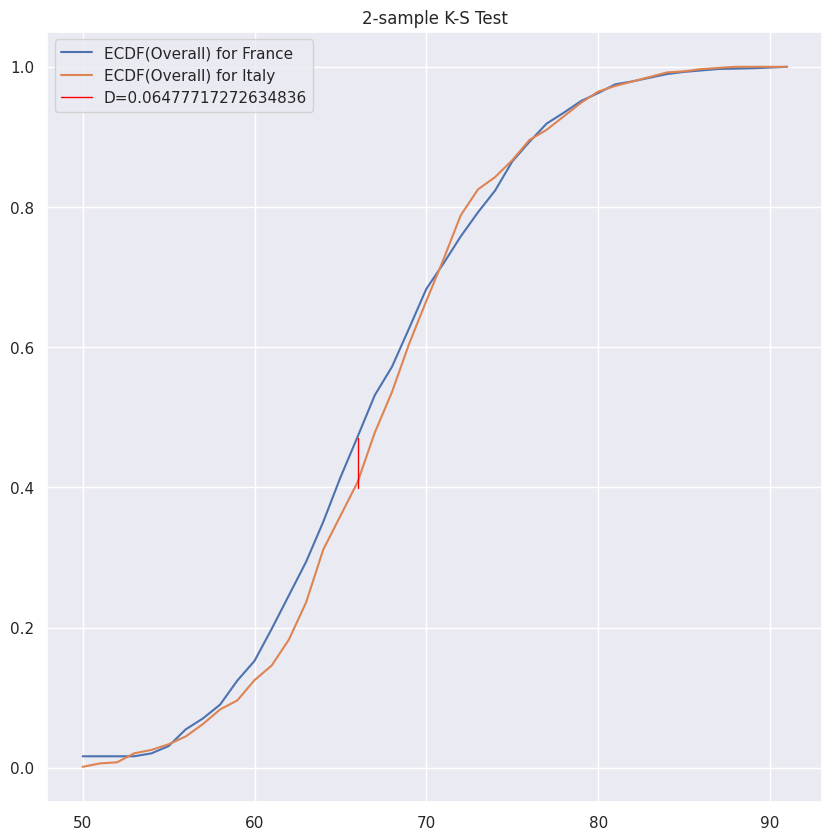

In [ ]:
D_argmax = abs(ecdf1_interp - ecdf2_interp).argmax()
D_fr, D_it = ecdf1_interp[D_argmax], ecdf2_interp[D_argmax]

plt.figure(figsize=(10, 10))
plt.plot(all_values, ecdf1_interp, label="ECDF(Overall) for France")
plt.plot(all_values, ecdf2_interp, label="ECDF(Overall) for Italy")
plt.axvline(D_argmax + all_values[0], ymin=min(D_fr, D_it), ymax=max(D_fr, D_it), label=f"D={D}", color="red", linewidth=1)
plt.title("2-sample K-S Test")
plt.legend()

In [ ]:
# two-sample Welch T-test
n1, n2 = len(fr), len(it)
m1, m2 = np.mean(fr), np.mean(it)
v1, v2 = np.var(fr, ddof=1), np.var(it, ddof=1)

t_stat = (m1 - m2) / np.sqrt(v1/n1 + v2/n2)
dfr = (v1/n1 + v2/n2)**2 / ((v1**2)/(n1**2*(n1-1)) + (v2**2)/(n2**2*(n2-1)))

t_crit = stats.t.ppf(1 - alpha/2, dfr)
p_value = 2 * stats.t.sf(abs(t_stat), dfr)

In [ ]:
print(f"Для теста Уэлча {t_stat=} \n{t_crit=} \t {p_value=}")
if t_stat > t_crit or p_value < alpha:
  print("Нулевая гипотеза отвергается")
else:
  print("Нулевая гипотеза не может быть отвергнута")

Для теста Уэлча t_stat=np.float64(-1.230458220574787) 
t_crit=np.float64(1.961700759019865) 	 p_value=np.float64(0.21873723611306908)
Нулевая гипотеза не может быть отвергнута


In [ ]:
mann = stats.mannwhitneyu(fr, it)
mann_stat = mann.statistic.item()
p_value = mann.pvalue.item()
print(f"Для теста Манна-Уитни {mann_stat=} \t {p_value=}")
if p_value < alpha:
  print("Нулевая гипотеза отвергается")
else:
  print("Нулевая гипотеза не может быть отвергнута")

Для теста Манна-Уитни mann_stat=285740.0 	 p_value=0.10967960257059065
Нулевая гипотеза не может быть отвергнута


### Задание 3

*Связаны ли рейтинг футболиста и его национальность?*

Будет использоваться коэффициент корреляции Спирмена и анализ ANOVA

$H_0$: все группы имеют одинаковые средние

$H_a$: не все группы имеют одинаковые средние

In [ ]:
nationality_codes = {nat: i for i, nat in enumerate(df["Nationality"].unique())}
df["NationalityCode"] = df["Nationality"].map(nationality_codes)

df["Rank_Overall"] = df["Overall"].rank()
df["Rank_Nationality"] = df["NationalityCode"].rank()

df["d"] = df["Rank_Overall"] - df["Rank_Nationality"]
df["d_squared"] = df["d"] ** 2

n = len(df)
spearman_r = 1 - (6 * df["d_squared"].sum() / (n * (n**2 - 1)))

print("Коэффициент Спирмена:", spearman_r)

Коэффициент Спирмена: -0.1975118628313408


In [ ]:
nationalities = df["Nationality"].unique()
groups = [df[df["Nationality"] == nationality]["Overall"] for nationality in nationalities]

grand_mean = np.concatenate(groups).mean()

# Межгрупповая дисперсия (SS_between)
ss_between = sum(len(group) * (group.mean() - grand_mean) ** 2 for group in groups)
df_between = len(groups) - 1
ms_between = ss_between / df_between

# Внутригрупповая дисперсия (SS_within)
ss_within = sum(((group - group.mean())**2).sum() for group in groups)
df_within = sum(len(group) - 1 for group in groups)
ms_within = ss_within / df_within

f_statistic = (ms_between / ms_within).item()
F_crit = stats.f.ppf(1 - alpha, dfn=df_between, dfd=df_within).item()

p_value = (1 - stats.f.cdf(f_statistic, dfn=df_between, dfd=df_within)).item()

In [ ]:
print(f"Для дисперсионного анализа ANOVA {f_statistic=} \n{F_crit=}\t {p_value=}")
if f_statistic > F_crit or p_value < alpha:
  print("Нулевая гипотеза отвергается")
else:
  print("Нулевая гипотеза не может быть отвергнута")

Для дисперсионного анализа ANOVA f_statistic=33.17818412422201 
F_crit=1.1923966556869814	 p_value=1.1102230246251565e-16
Нулевая гипотеза отвергается


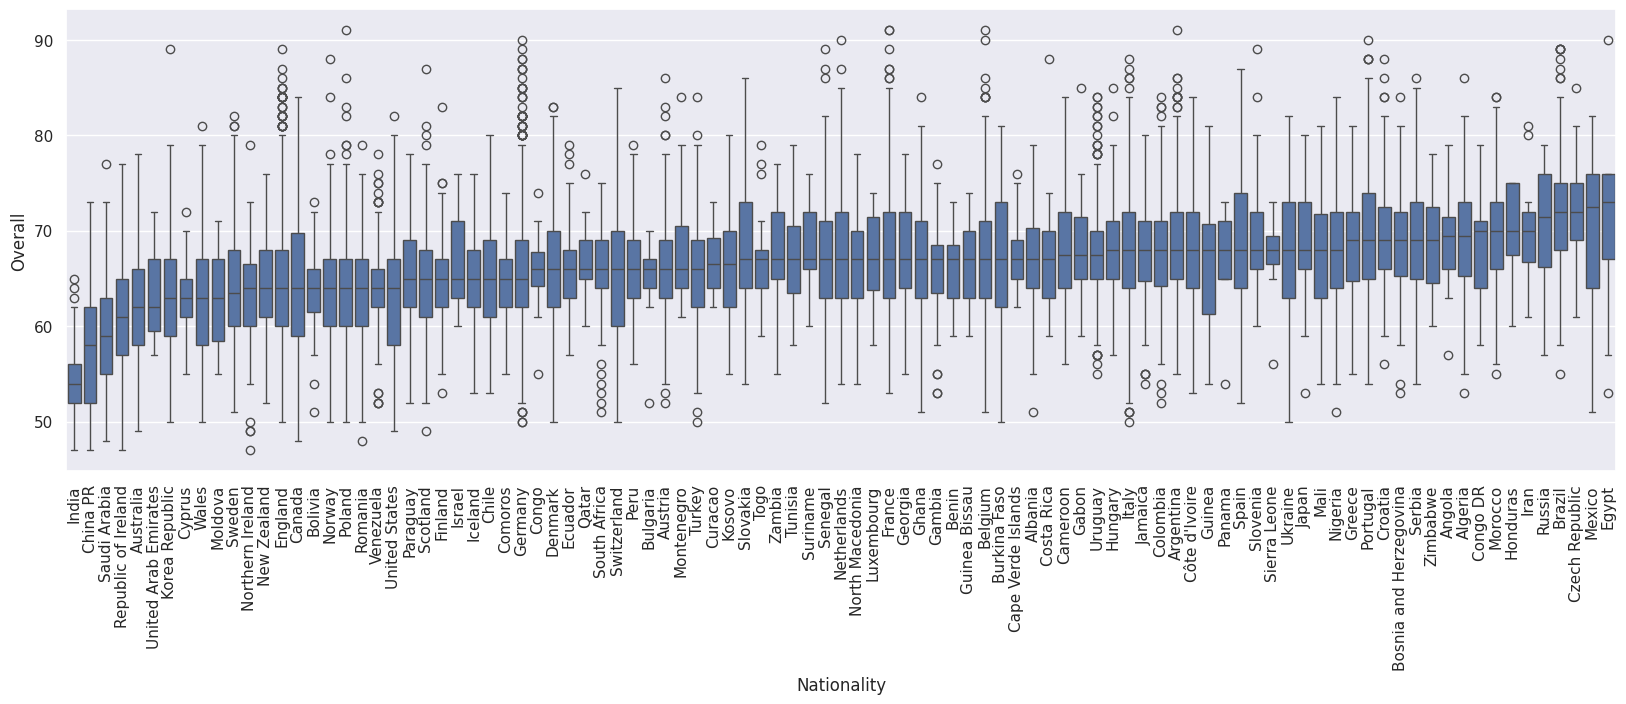

In [ ]:
nat_vc = df["Nationality"].value_counts()
countries = nat_vc[nat_vc > 10].index.tolist()
to_box = df[df["Nationality"].isin(countries)]

medians = to_box.groupby("Nationality")["Overall"].median().sort_values()
sorted_nationalities = medians.index

plt.figure(figsize=(20, 6))
sns.boxplot(to_box, y="Overall", x="Nationality", order=sorted_nationalities)
plt.xticks(rotation=90)
plt.show()